In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

transactions = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(nav.shape)
print(transactions.shape)
print(performance.shape)
print(holdings.shape)


(46000, 3)
(32778, 13)
(40, 19)
(322, 8)


In [4]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [6]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')


In [7]:
var_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_list.append([
        code,
        var_95,
        cvar_95
    ])

var_df = pd.DataFrame(
    var_list,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

print(var_df.head())
print(var_df.shape)

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459
(40, 3)


In [8]:
var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print(
    "var_cvar_report.csv saved successfully"
)

var_cvar_report.csv saved successfully


In [9]:
print(var_df.shape)

(40, 3)


In [10]:
performance[[
    "amfi_code",
    "scheme_name"
]].head()

,amfi_code,scheme_name
0,119551,SBI Bluechip Fund - Regular Plan - Growth
1,119552,SBI Bluechip Fund - Direct Plan - Growth
2,119598,SBI Small Cap Fund - Regular Plan - Growth
3,119599,SBI Small Cap Fund - Direct Plan - Growth
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth


In [11]:
top5 = performance.head(5)

print(
    top5[
        ["amfi_code", "scheme_name"]
    ]
)

   amfi_code                                   scheme_name
0     119551     SBI Bluechip Fund - Regular Plan - Growth
1     119552      SBI Bluechip Fund - Direct Plan - Growth
2     119598    SBI Small Cap Fund - Regular Plan - Growth
3     119599     SBI Small Cap Fund - Direct Plan - Growth
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth


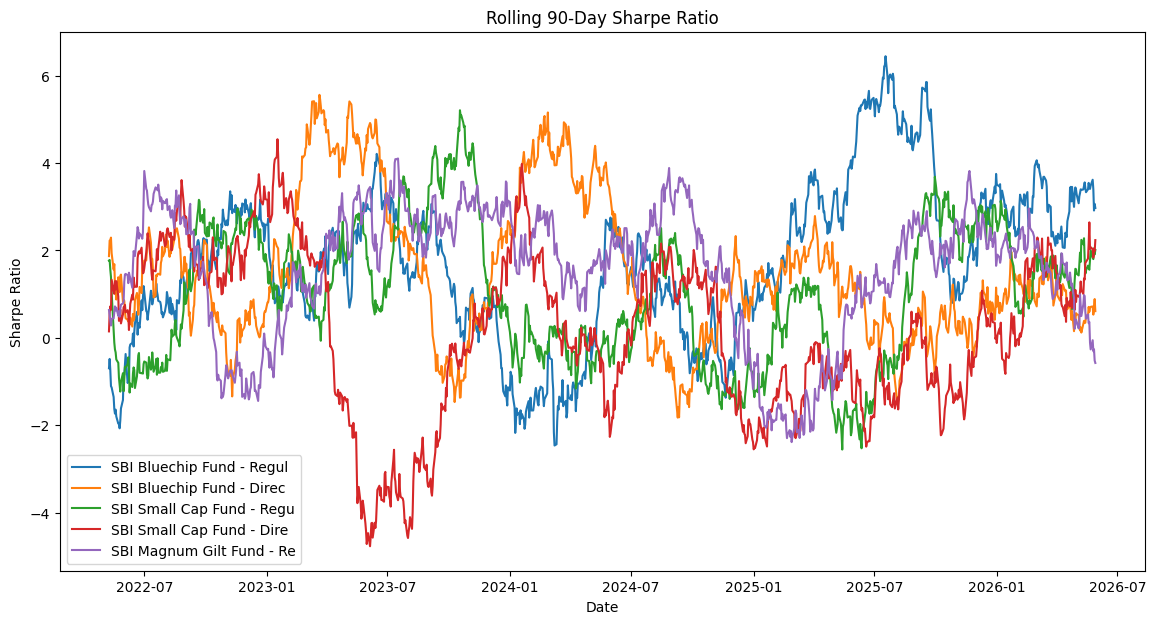

In [12]:
plt.figure(figsize=(14,7))

for code in top5["amfi_code"]:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    rolling_mean = (
        fund["daily_return"]
        .rolling(90)
        .mean()
    )

    rolling_std = (
        fund["daily_return"]
        .rolling(90)
        .std()
    )

    rolling_sharpe = (
        rolling_mean
        /
        rolling_std
    ) * np.sqrt(252)

    fund_name = (
        performance.loc[
            performance["amfi_code"] == code,
            "scheme_name"
        ]
        .iloc[0]
    )

    plt.plot(
        fund["date"],
        rolling_sharpe,
        label=fund_name[:25]
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend()

plt.show()

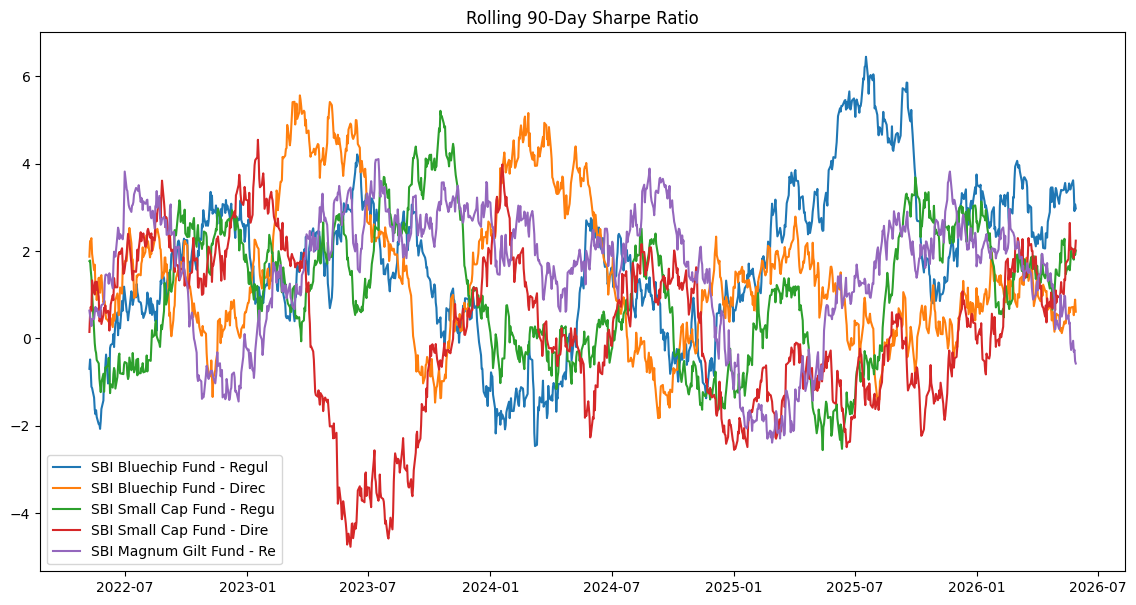

rolling_sharpe_chart.png saved successfully


In [13]:
plt.figure(figsize=(14,7))

for code in top5["amfi_code"]:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    rolling_mean = (
        fund["daily_return"]
        .rolling(90)
        .mean()
    )

    rolling_std = (
        fund["daily_return"]
        .rolling(90)
        .std()
    )

    rolling_sharpe = (
        rolling_mean
        /
        rolling_std
    ) * np.sqrt(252)

    fund_name = (
        performance.loc[
            performance["amfi_code"] == code,
            "scheme_name"
        ]
        .iloc[0]
    )

    plt.plot(
        fund["date"],
        rolling_sharpe,
        label=fund_name[:25]
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.legend()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

print(
    "rolling_sharpe_chart.png saved successfully"
)

In [14]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["cohort_year"] = (
    transactions.groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

print(
    transactions[
        ["investor_id", "cohort_year"]
    ].head()
)

  investor_id  cohort_year
0   INV003054         2024
1   INV002952         2024
2   INV003420         2024
3   INV003436         2024
4   INV004691         2024


In [15]:
cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_amount=("amount_inr","mean"),
        total_invested=("amount_inr","sum"),
        investors=("investor_id","nunique")
    )
    .reset_index()
)

print(cohort_summary)

   cohort_year     avg_amount  total_invested  investors
0         2024  107422.541832      3491125187       4803
1         2025  109158.577061        30455243        197


In [16]:
top_funds = (
    transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_funds = (
    top_funds
    .sort_values(
        ["cohort_year","count"],
        ascending=[True,False]
    )
    .groupby("cohort_year")
    .head(1)
)

print(top_funds)

    cohort_year  amfi_code  count
35         2024     148568    874
62         2025     119599     12


In [17]:
top_funds = top_funds.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

print(
    top_funds[
        [
            "cohort_year",
            "scheme_name",
            "count"
        ]
    ]
)

   cohort_year                                        scheme_name  count
0         2024  Mirae Asset Emerging Bluechip Fund - Regular -...    874
1         2025          SBI Small Cap Fund - Direct Plan - Growth     12


## Investor Cohort Analysis

- Cohorts were created using each investor's first transaction year.
- Average investment amount differs across cohorts.
- Total invested amount highlights which cohort contributes most capital.
- Top fund preference was identified using transaction frequency.

In [18]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

print(sip_txn.shape)

(0, 14)


In [19]:
sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

print(
    sip_txn.head()
)

Empty DataFrame
Columns: [investor_id, transaction_date, amfi_code, transaction_type, amount_inr, state, city, city_tier, age_group, gender, annual_income_lakh, payment_mode, kyc_status, cohort_year]
Index: []


In [20]:
sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

print(
    sip_txn[
        ["investor_id","gap_days"]
    ].head(10)
)

Empty DataFrame
Columns: [investor_id, gap_days]
Index: []


In [21]:
sip_continuity = (
    sip_txn
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date","count"),
        avg_gap_days=("gap_days","mean")
    )
    .reset_index()
)

print(
    sip_continuity.head()
)

Empty DataFrame
Columns: [investor_id, sip_count, avg_gap_days]
Index: []


In [22]:
sip_continuity = sip_continuity[
    sip_continuity["sip_count"] >= 6
]

print(
    sip_continuity.shape
)

(0, 3)


In [23]:
sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At Risk",
    "Active"
)

print(
    sip_continuity["status"]
    .value_counts()
)

Series([], Name: count, dtype: int64)


## SIP Continuity Analysis

- Investors with at least 6 SIP transactions were analysed.
- Average gap between SIP dates was calculated.
- Investors with average gap greater than 35 days were classified as At Risk.
- Active investors maintain more regular SIP schedules.

In [24]:
print(
    performance["risk_grade"]
    .value_counts()
)

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [25]:
hhi = (
    holdings
    .groupby("amfi_code")
    ["weight_pct"]
    .apply(
        lambda x: (x/100)**2
        .sum()
    )
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

print(
    hhi.head()
)

AttributeError: 'int' object has no attribute 'sum'

In [26]:
print(holdings["weight_pct"].dtype)

print(
    holdings["weight_pct"].head()
)

float64
0    13.85
1    11.19
2     9.90
3     4.76
4    10.25
Name: weight_pct, dtype: float64


In [27]:
holdings["weight_pct"] = pd.to_numeric(
    holdings["weight_pct"],
    errors="coerce"
)

print(
    holdings["weight_pct"].dtype
)

float64


In [28]:
hhi = (
    holdings.groupby("amfi_code")
    ["weight_pct"]
    .apply(
        lambda x: ((x/100) ** 2).sum()
    )
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

print(hhi.head())
print(hhi.shape)

   amfi_code       HHI
0     100016  0.139534
1     100033  0.147592
2     101206  0.129332
3     101207  0.200700
4     102885  0.174709
(34, 2)


In [29]:
hhi.to_csv(
    "../reports/hhi_report.csv",
    index=False
)

print("HHI report saved successfully")

HHI report saved successfully


In [30]:
print(
    performance["risk_grade"]
    .value_counts()
)

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


## Fund Recommender

A simple recommendation engine was created using risk grades and Sharpe Ratio rankings.

- Low Risk → Low risk funds
- Moderate Risk → Moderate and Moderately High funds
- High Risk → High and Very High funds

Top 3 funds are recommended based on risk-adjusted performance.